## Классическая нейронная сеть для коррекции вектора состояний.
### На вход подается вектор состояний с шумного симулятора. На выходе из нейронной сети получается скорректированный вектор состояний. В качестве истинной метки используется вектор состояний с идеального симулятора.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

import ast
import re

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.visualization import plot_histogram


## 1. Чтение векторов из датасета

In [3]:
ideal_measure_vectors = []
noisy_measure_vectors = []

with open('2-dataset.txt', 'r', encoding='utf-8') as f:
  for line in f:
    lists = re.findall(r'\[.*?\]', line)
    second_list = ast.literal_eval(lists[1])
    third_list = ast.literal_eval(lists[2])
    ideal_measure_vectors.append(second_list)
    noisy_measure_vectors.append(third_list)

#print(ideal_measure_vectors)
print(f"Number of ideal measure vectors: {len(ideal_measure_vectors)}")
#print(noisy_measure_vectors)
print(f"Number of noisy measure vectors: {len(noisy_measure_vectors)}")

fidelity = 0
for i in range(len(ideal_measure_vectors)):
  dot_product = np.dot(np.array(ideal_measure_vectors[i]), np.array(noisy_measure_vectors[i]))
  ideal_norm = np.linalg.norm(np.array(ideal_measure_vectors[i]))
  noisy_norm = np.linalg.norm(np.array(noisy_measure_vectors[i]))
  fidelity += (dot_product / (ideal_norm * noisy_norm + 1e-8)) ** 2

average_fidelity_without_correction = fidelity / len(ideal_measure_vectors)
print(f"Fidelity для нескорректированных векторов: {average_fidelity_without_correction:.4f}")

Number of ideal measure vectors: 1088
Number of noisy measure vectors: 1088
Fidelity для нескорректированных векторов: 0.9893


## 2. Подготовка модели

In [144]:
n_samples = noisy_measure_vectors
dim = len(noisy_measure_vectors[0])

X_noisy = np.array(noisy_measure_vectors)
y_ideal = np.array(ideal_measure_vectors)

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y_ideal, test_size=0.25, random_state=42
)

class RegressionModel(nn.Module):
  def __init__(self, input_dim=dim, output_dim = dim):
    super(RegressionModel, self).__init__()
    
    self.net = nn.Sequential(
      nn.Linear(input_dim, 32),
      nn.ReLU(),
      nn.Linear(32, 64),
      nn.ReLU(),
      nn.Linear(64, 64),
      nn.ReLU(),
      nn.Dropout(0.1),
      nn.Linear(64, output_dim),
      nn.Softmax(1)
    )

  def forward(self, x):
    return self.net(x)

  def predict(self, x):
    with torch.no_grad():
      output = self.forward(x)
      return torch.round(output)
    
model = RegressionModel(input_dim=dim, output_dim=dim)
print("Архитектура модели:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params}")
print(f"Обучаемых параметров: {trainable_params}")


Архитектура модели:
RegressionModel(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=64, out_features=8, bias=True)
    (8): Softmax(dim=1)
  )
)

Всего параметров: 7080
Обучаемых параметров: 7080


## 3. Подготовка данных

In [145]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_reg = torch.tensor(y_train, dtype=torch.float32)
y_test_reg = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_reg)
test_dataset = TensorDataset(X_test_tensor, y_test_reg)

batch_size = 1

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Разные
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # по 1

# Проверка того, что всё собрано верно
print(f"Форма X_train: {X_train_tensor.shape}")
print(f"Форма y_train: {y_train_reg.shape}") 
print(f"Размер батча: {batch_size}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")


Форма X_train: torch.Size([816, 8])
Форма y_train: torch.Size([816, 8])
Размер батча: 1
Количество батчей в обучающей выборке: 816
Количество батчей в тестовой выборке: 272


## 4. Обучение модели

In [146]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
def train_model(model, train_loader, test_loader, epochs=50, learning_rate=0.01):
    # Для регрессии используем MSE
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    train_fidelities = []
    test_losses = []
    test_fidelities = []
    
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max',
        factor=0.5,
        threshold=0.005,
        cooldown=10,  
        patience=20,
        min_lr=1e-6
    )

    print("Начинаем обучение (регрессия с метрикой Accuracy)...")
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        total_train_fidelity = 0
        train_total = 0
        
        for _, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            dot_products = torch.sum(output * target, dim=1)
            pred_norms = torch.norm(output, dim=1)
            target_norms = torch.norm(target, dim=1)
            fidelity = (dot_products / (pred_norms * target_norms + 1e-8)) ** 2
            total_train_fidelity += fidelity.sum().item()
            train_total += target.size(0)
            
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_fidelity = total_train_fidelity / train_total
        
        model.eval()
        total_test_loss = 0
        total_test_fidelity = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                loss = loss_function(output, target)
                total_test_loss += loss.item()
                
                # Вычисление fidelity - перекрытия
                dot_products = torch.sum(output * target, dim=1)
                pred_norms = torch.norm(output, dim=1)
                target_norms = torch.norm(target, dim=1)
                fidelity = (dot_products / (pred_norms * target_norms + 1e-8)) ** 2
                total_test_fidelity += fidelity.sum().item()
                test_total += target.size(0)
        
        avg_test_loss = total_test_loss / len(test_loader)
        avg_test_fidelity = total_test_fidelity / test_total

        train_losses.append(avg_train_loss)
        train_fidelities.append(avg_train_fidelity)
        test_losses.append(avg_test_loss)
        test_fidelities.append(avg_test_fidelity)

        # scheduler.step(avg_test_fidelity)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            clear_output(wait=True)
            print(f"Эпоха {epoch+1}/{epochs}:")
            print(f"  Обучающая выборка: loss={avg_train_loss:.6f}, fidelity={avg_train_fidelity:.4f}")
            print(f"  Тестовая выборка:  loss={avg_test_loss:.6f}, fidelity={avg_test_fidelity:.4f}")
    
    print("\nОбучение завершено!")
    
    return train_losses, train_fidelities, test_losses, test_fidelities

epochs = 500 # Количество эпох обучения (можно изменять)
learning_rate = 0.0001 # Скорость обучения (можно изменять)

train_losses, train_fidelities, test_losses, test_fidelities = train_model(
    model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
)

Эпоха 500/500:
  Обучающая выборка: loss=0.000424, fidelity=0.9896
  Тестовая выборка:  loss=0.000308, fidelity=0.9927

Обучение завершено!


## 5. Визуализация процесса обучения

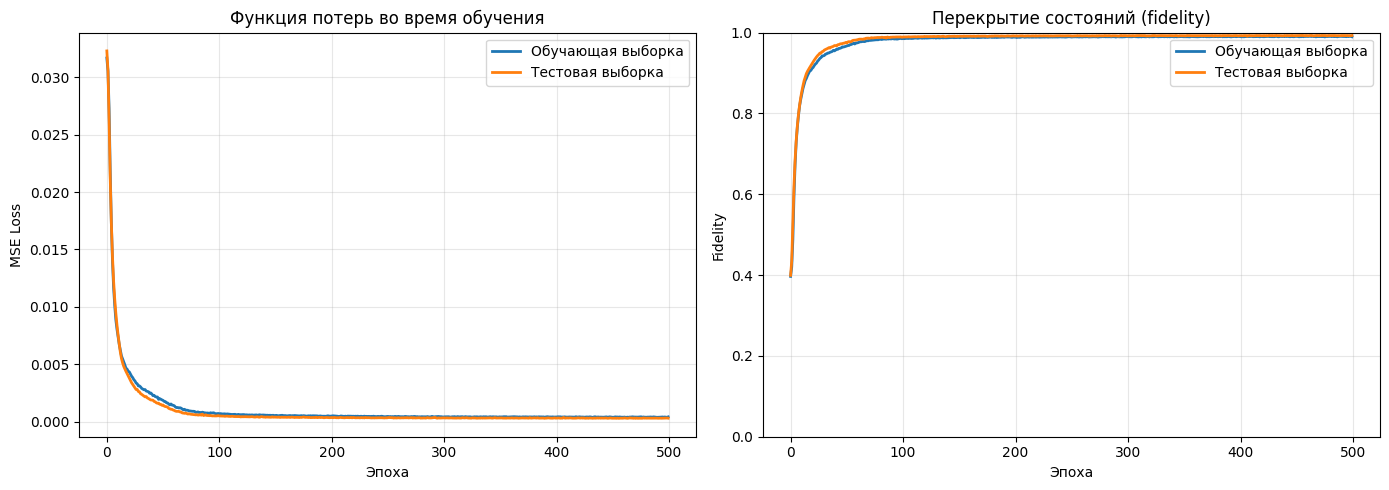

Финальная fidelity на обучающей выборке: 0.9896
Финальная fidelity на тестовой выборке: 0.9927


In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Обучающая выборка', linewidth=2)
axes[0].plot(test_losses, label='Тестовая выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Функция потерь во время обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_fidelities, label='Обучающая выборка', linewidth=2)
axes[1].plot(test_fidelities, label='Тестовая выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Fidelity')
axes[1].set_title('Перекрытие состояний (fidelity)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Финальная fidelity на обучающей выборке: {train_fidelities[-1]:.4f}")
print(f"Финальная fidelity на тестовой выборке: {test_fidelities[-1]:.4f}")



## 6. Визуализация предсказаний

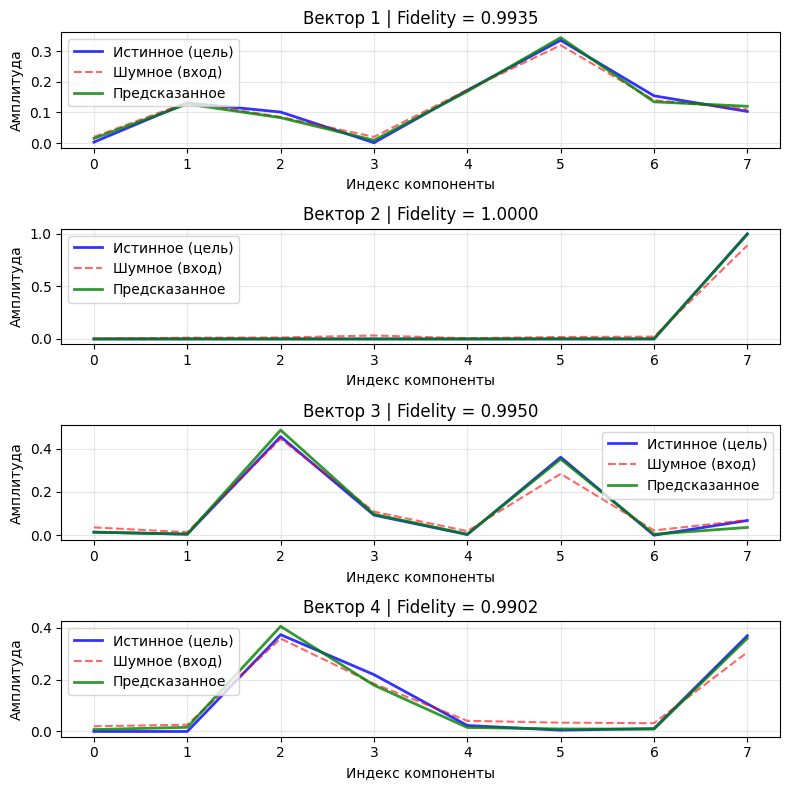

In [148]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test[:4], dtype=torch.float32)
    predictions = model(X_test_tensor).numpy()

fig, axes = plt.subplots(4, 1, figsize=(8, 8))

for i in range(4):
    dot = np.dot(predictions[i], y_test[i])
    fid = (dot / (np.linalg.norm(predictions[i]) * np.linalg.norm(y_test[i])))**2
    
    axes[i].plot(y_test[i], 'b-', label='Истинное (цель)', alpha=0.8, linewidth=2)
    axes[i].plot(X_test[i], 'r--', label='Шумное (вход)', alpha=0.6)
    axes[i].plot(predictions[i], 'g-', label='Предсказанное', alpha=0.8, linewidth=2)
    axes[i].set_title(f"Вектор {i+1} | Fidelity = {fid:.4f}")
    axes[i].set_xlabel("Индекс компоненты")
    axes[i].set_ylabel("Амплитуда")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
import torch
import numpy as np

# 1. Переводим модель в режим предсказания
model.eval()

test_predictions = []
test_inputs_list = []
test_targets_list = []

# Отключаем градиенты для ускорения
with torch.no_grad():
    for inputs, targets in test_loader:
        # Получаем выход модели
        outputs = model(inputs)
        
        # Если в конце модели нет Softmax, можно добавить его здесь для уверенности:
        # outputs = torch.softmax(outputs, dim=1)
        
        test_predictions.append(outputs.cpu().numpy())
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

# Объединяем батчи в единые массивы
final_preds = np.vstack(test_predictions)
final_inputs = np.vstack(test_inputs_list)
final_targets = np.vstack(test_targets_list)

# 2. Сохраняем в файл в красивом формате
with open("test_results.txt", "w") as f:
    for i in range(len(final_preds)):
        # Превращаем массивы в чистые списки Python для записи
        in_vec = [round(float(x), 5) for x in final_inputs[i]]
        target_vec = [round(float(x), 5) for x in final_targets[i]]
        pred_vec = [round(float(x), 5) for x in final_preds[i]]
        
        f.write(f"In: {in_vec} | Tar: {target_vec} | Pred: {pred_vec}\n")

print(f"Готово! Сохранено {len(final_preds)} предсказаний в файл test_results.txt")

# Выведем одно предсказание для визуальной проверки
print("\nПример первого предсказания из теста:")
print(f"Target (Идеал):  {target_vec}")
print(f"Predict (Нейро): {pred_vec}")

Готово! Сохранено 272 предсказаний в файл test_results.txt

Пример первого предсказания из теста:
Target (Идеал):  [0.511, 0.0, 0.0, 0.0, 0.489, 0.0, 0.0, 0.0]
Predict (Нейро): [0.51085, 0.00197, 0.00132, 0.00244, 0.47779, 0.00126, 0.00187, 0.0025]
